# Improved CNN

This notebook improves upon the baseline CNN by introducing:

- Data Augmentation
- Batch Normalization
- Early Stopping
- Model Checkpointing
- Class Weights

The goal is to improve generalization and reduce the effects of class imbalance.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
PROCESSED_PATH = "/content/drive/MyDrive/emotion_sentiment_fusion_detector/data/processed"

X_train = np.load(f"{PROCESSED_PATH}/X_train.npy")
X_val = np.load(f"{PROCESSED_PATH}/X_val.npy")
X_test = np.load(f"{PROCESSED_PATH}/X_test.npy")

y_train = np.load(f"{PROCESSED_PATH}/y_train.npy")
y_val = np.load(f"{PROCESSED_PATH}/y_val.npy")
y_test = np.load(f"{PROCESSED_PATH}/y_test.npy")

# Data Augmentation

The baseline model overfit the training data.

Data augmentation artificially creates new training examples through small image transformations.

This helps the CNN generalize better to unseen faces.

In [ ]:
train_datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.10,
    horizontal_flip=True
)

# Batch Normalization

Batch Normalization normalizes activations during training.

Benefits:

- Faster training
- More stable gradients
- Better generalization
- Reduced sensitivity to initialization

In [ ]:
model = Sequential()

# BLOCK 1

model.add(
    Conv2D(
        32,
        (3,3),
        activation="relu",
        input_shape=(48,48,1)
    )
)

model.add(BatchNormalization())

model.add(
    MaxPooling2D((2,2))
)

# BLOCK 2

model.add(
    Conv2D(
        64,
        (3,3),
        activation="relu"
    )
)

model.add(BatchNormalization())

model.add(
    MaxPooling2D((2,2))
)

# BLOCK 3

model.add(
    Conv2D(
        128,
        (3,3),
        activation="relu"
    )
)

model.add(BatchNormalization())

model.add(
    MaxPooling2D((2,2))
)

model.add(Flatten())

model.add(
    Dense(
        128,
        activation="relu"
    )
)

model.add(
    Dropout(0.5)
)

model.add(
    Dense(
        7,
        activation="softmax"
    )
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Class Weights

FER2013 contains severe class imbalance.

The disgust class has significantly fewer examples than other emotions.

Class weights force the model to pay more attention to underrepresented classes during training.

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

In [ ]:
y_train_labels = np.argmax(
    y_train,
    axis=1
)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_labels),
    y=y_train_labels
)

class_weights = dict(
    enumerate(class_weights)
)

print(class_weights)# Early Stopping



{0: np.float64(1.0265957446808511), 1: np.float64(9.401146131805158), 2: np.float64(1.0012206286237413), 3: np.float64(0.5684338184338185), 4: np.float64(0.8260322255790534), 5: np.float64(0.849120082815735), 6: np.float64(1.2932597556168703)}


# Early Stopping

Training stops automatically when validation performance stops improving.

This reduces overfitting.

In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [ ]:
checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/emotion_sentiment_fusion_detector/models/improved/best_emotion_model.keras",
    monitor="val_accuracy",
    save_best_only=True
)

In [ ]:
import os

os.makedirs(
    "/content/drive/MyDrive/emotion_sentiment_fusion_detector/models/improved",
    exist_ok=True
)

In [ ]:
history = model.fit(
    train_datagen.flow(
        X_train,
        y_train,
        batch_size=64
    ),

    validation_data=(
        X_val,
        y_val
    ),

    epochs=50,

    callbacks=[
        early_stop,
        checkpoint
    ],

    class_weight=class_weights
)

Epoch 1/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 135s 368ms/step - accuracy: 0.1837 - loss: 1.9925 - val_accuracy: 0.2079 - val_loss: 1.9736
Epoch 2/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 127s 353ms/step - accuracy: 0.2157 - loss: 1.8610 - val_accuracy: 0.2623 - val_loss: 1.7823
Epoch 3/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 130s 362ms/step - accuracy: 0.2275 - loss: 1.8136 - val_accuracy: 0.2558 - val_loss: 1.7700
Epoch 4/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 127s 355ms/step - accuracy: 0.2384 - loss: 1.7698 - val_accuracy: 0.3304 - val_loss: 1.6776
Epoch 5/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 127s 353ms/step - accuracy: 0.2687 - loss: 1.7304 - val_accuracy: 0.3589 - val_loss: 1.6161
Epoch 6/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 130s 361ms/step - accuracy: 0.2966 - loss: 1.7138 - val_accuracy: 0.3912 - val_loss: 1.5913
Epoch 7/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 131s 364ms/step - accuracy: 0.3281 - loss: 1.6784 - val_accuracy: 0.2865 - val_loss: 1.7295
Epoch 8/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 126s 350ms/step - accuracy: 0.3453 -

In [ ]:
model.save(
    "/content/drive/MyDrive/emotion_sentiment_fusion_detector/models/improved/emotion_improved.keras"
)

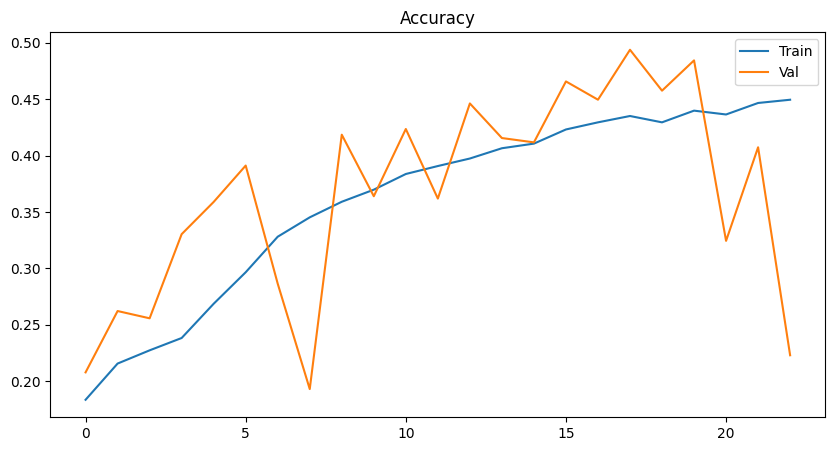

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.legend(["Train","Val"])
plt.title("Accuracy")

plt.show()

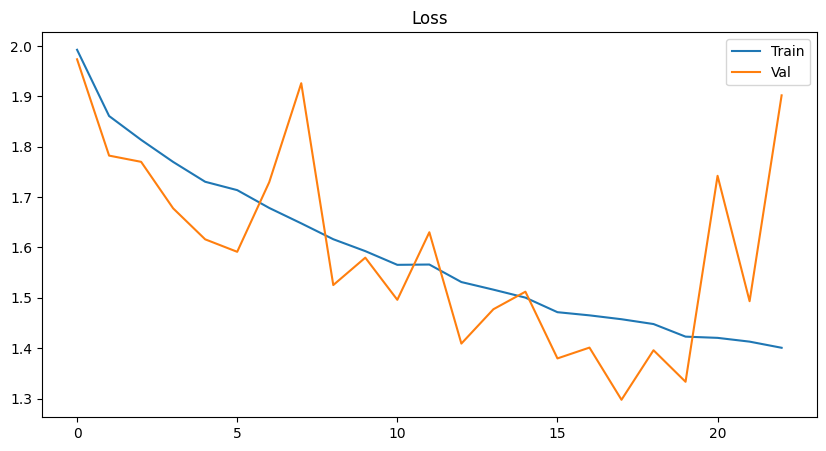

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.legend(["Train","Val"])
plt.title("Loss")

plt.show()

In [ ]:
import os

print(
    os.path.exists(
        "/content/drive/MyDrive/emotion_sentiment_fusion_detector/models/improved/best_emotion_model.keras"
    )
)

True
